SVM Classfier trained with 1 datapoints：数据是线性可分的
分类器的超平面系数为：w=[ 0.          0.00050195 -0.00276071 -0.00250974  0.00406577  0.03119602], b=-1.281643386620361
SVM Classfier trained with 1 datapoints：间隔为 63.1228


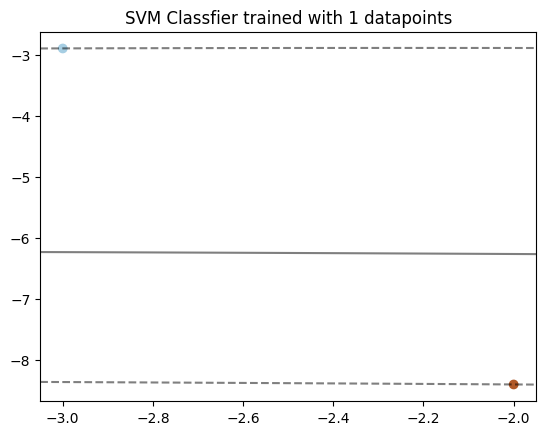

SVM Classfier trained with 2 datapoints：数据是线性可分的
分类器的超平面系数为：w=[ 0.         -0.01211095 -0.07388063  0.0413511   0.05342728  0.02219439], b=-2.274024975733787
SVM Classfier trained with 2 datapoints：间隔为 19.3692


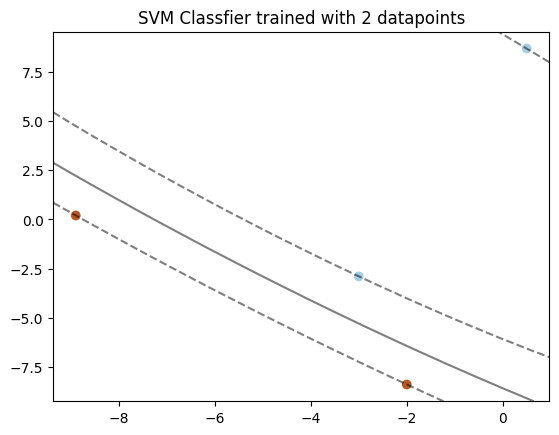

SVM Classfier trained with 3 datapoints：数据是线性可分的
分类器的超平面系数为：w=[ 8.67361738e-19 -1.21103944e-02 -7.38800900e-02  4.13468195e-02
  5.34276434e-02  2.22001672e-02], b=-2.2741498950924477
SVM Classfier trained with 3 datapoints：间隔为 19.3693


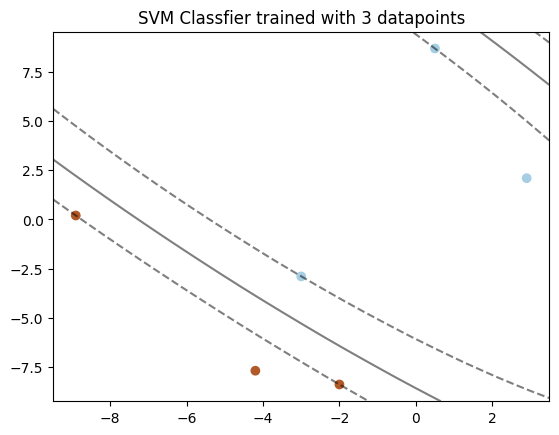

SVM Classfier trained with 4 datapoints：数据是线性可分的
分类器的超平面系数为：w=[-8.67361738e-19 -1.21106580e-02 -7.38849139e-02  4.13399760e-02
  5.34313513e-02  2.21863083e-02], b=-2.2734855101151314
SVM Classfier trained with 4 datapoints：间隔为 19.3694


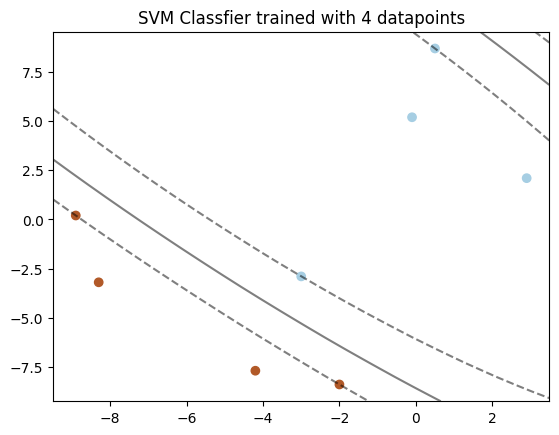

SVM Classfier trained with 5 datapoints：数据是线性可分的
分类器的超平面系数为：w=[-4.33680869e-19 -1.21105557e-02 -7.38832668e-02  4.13440551e-02
  5.34303389e-02  2.21993150e-02], b=-2.274074397316779
SVM Classfier trained with 5 datapoints：间隔为 19.3688


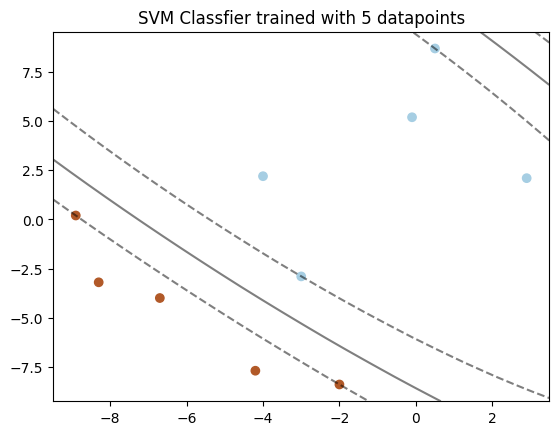

SVM Classfier trained with 6 datapoints：数据是线性可分的
分类器的超平面系数为：w=[-4.33680869e-19 -1.21105635e-02 -7.38825437e-02  4.13431393e-02
  5.34294094e-02  2.21904734e-02], b=-2.273704349877027
SVM Classfier trained with 6 datapoints：间隔为 19.3695


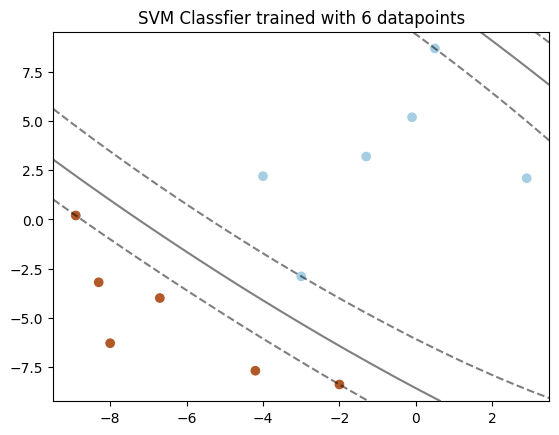

SVM Classfier trained with 7 datapoints：数据是线性可分的
分类器的超平面系数为：w=[-8.67361738e-19 -1.21112000e-02 -7.38861792e-02  4.13457929e-02
  5.34320071e-02  2.21922380e-02], b=-2.273856477743193
SVM Classfier trained with 7 datapoints：间隔为 19.3684


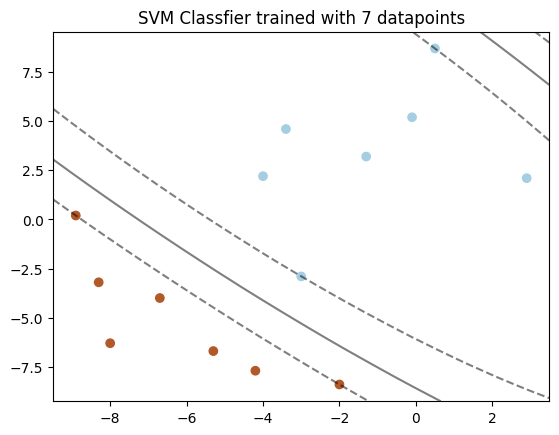

SVM Classfier trained with 8 datapoints：数据是线性可分的
分类器的超平面系数为：w=[-1.30104261e-18 -1.21102089e-02 -7.38816337e-02  4.13394927e-02
  5.34289106e-02  2.21867920e-02], b=-2.2734724471948513
SVM Classfier trained with 8 datapoints：间隔为 19.3701


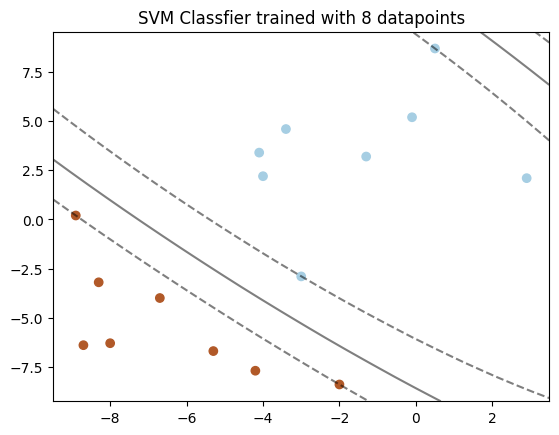

SVM Classfier trained with 9 datapoints：数据是线性可分的
分类器的超平面系数为：w=[-1.30104261e-18 -1.21108140e-02 -7.38832481e-02  4.13455950e-02
  5.34298143e-02  2.21929244e-02], b=-2.2738600088475236
SVM Classfier trained with 9 datapoints：间隔为 19.3690


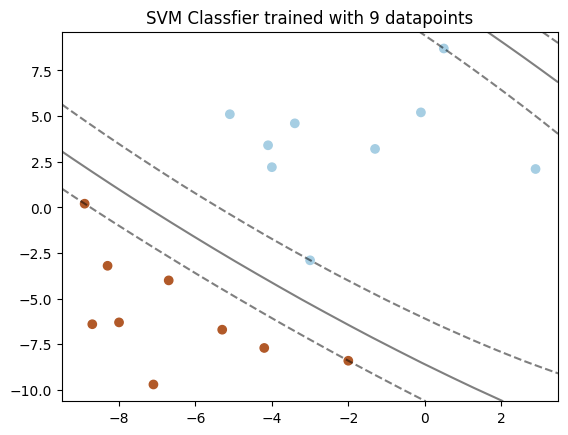

SVM Classfier trained with 10 datapoints：数据是线性可分的
分类器的超平面系数为：w=[-8.67361738e-19 -1.21103853e-02 -7.38819245e-02  4.13418102e-02
  5.34290449e-02  2.21898434e-02], b=-2.273645734529162
SVM Classfier trained with 10 datapoints：间隔为 19.3697


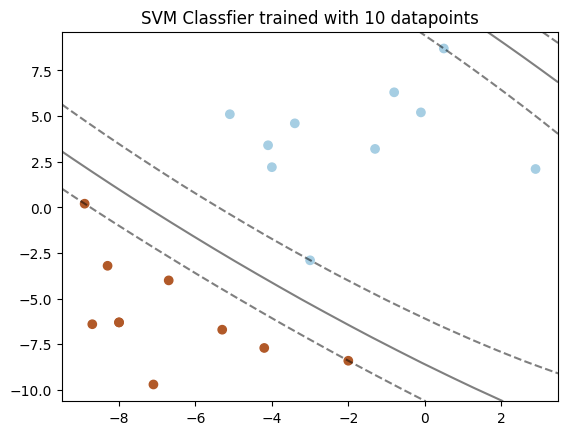

In [13]:
import numpy as np
from sklearn import svm
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score

# 定义数据
X = np.array([[-3.0, -2.9], [0.5, 8.7], [2.9, 2.1], [-0.1, 5.2], [-4.0, 2.2], [-1.3, 3.2], [-3.4, 4.6], [-4.1, 3.4], [-5.1, 5.1], [-0.8, 6.3], 
              [-2.0, -8.4], [-8.9, 0.2], [-4.2, -7.7], [-8.3, -3.2], [-6.7, -4.0], [-8.0, -6.3], [-5.3, -6.7], [-8.7, -6.4], [-7.1, -9.7], [-8.0, -6.3]])

y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,  # ω1的标签为1
              2, 2, 2, 2, 2, 2, 2, 2, 2, 2])  # ω2的标签为2

# 对数据进行预处理：构建新特征 (1, x1, x2, x1^2, x1*x2, x2^2)
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X)

# 创建SVM分类器
def train_and_plot_svm(X_origin, X_train, y_train, title):
    clf = svm.SVC(kernel='linear')
    clf.fit(X_train, y_train)

    # 获取训练准确率
    y_pred = clf.predict(X_train)
    accuracy = accuracy_score(y_train, y_pred)

    if accuracy == 1.0:
        print(f"{title}：数据是线性可分的")
    else:
        print(f"{title}：数据不是线性可分的")

    # 获取分割超平面参数
    w = clf.coef_[0]
    b = clf.intercept_[0]
    print(f"分类器的超平面系数为：w={w}, b={b}")
    margin = 2 / np.linalg.norm(w)  # 计算间隔值
    print(f"{title}：间隔为 {margin:.4f}")

    # 可视化分类结果
    plt.scatter(X_origin[:, 0], X_origin[:, 1], c=y_train, cmap=plt.cm.Paired)

    # 绘制决策边界
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # 创建网格来评估模型
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(poly.transform(xy)).reshape(XX.shape)

    # 绘制决策边界和边距
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    plt.title(title)
    plt.show()

train_size = len(X) // 2
for i in range(1, train_size + 1):
    X_origin = np.concatenate([X[:i],X[train_size:train_size+i]])
    X_train = np.concatenate([X_poly[:i],X_poly[train_size:train_size+i]])
    y_train = np.concatenate([y[:i],y[train_size:train_size+i]])
    title = f"SVM Classfier trained with {i} datapoints"
    train_and_plot_svm(X_origin,X_train, y_train, title)

